In [30]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [31]:
def aicc_weights_from_model_info(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for episode_data in data["bandwidth_optimization"]:
        bandwidth_raw = episode_data.get("bandwidth")
        if isinstance(bandwidth_raw, str):
            bandwidth_list = json.loads(bandwidth_raw)
        elif bandwidth_raw is None:
            bandwidth_list = []
        else:
            bandwidth_list = list(bandwidth_raw)

        rows.append({
            "episode": episode_data["episode"],
            "AICc": float(episode_data["reward"]),
            "bandwidth": bandwidth_list,
        })

    df = pd.DataFrame(rows).sort_values("episode").reset_index(drop=True)
    aicc_min = df["AICc"].min()
    df["Delta"] = df["AICc"] - aicc_min
    # Akaike weights
    lik = (df["Delta"] * -0.5).apply(math.exp)
    df["weight"] = lik / lik.sum()
    return df[["episode", "AICc", "Delta", "weight", "bandwidth"]]

def plot(b, sub_title=['', ''], size=40, vmin=None, vmax=None):
    k = len(b)
    fig, axs = plt.subplots(1, k, figsize=(6*k, 4))
    if k == 1:
        axs = [axs]
    for i in range(k):
        ax_img = axs[i].imshow(b[i].reshape(size, size),
                               cmap=colormaps['viridis'], vmin=vmin, vmax=vmax)
        axs[i].set_title(sub_title[i], fontsize=16)
        fig.colorbar(ax_img, ax=axs[i])
        axs[i].set_xticks(np.arange(-0.5, size, 5))
        axs[i].set_yticks(np.arange(-0.5, size, 5))
        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])
        axs[i].tick_params(axis='x', colors=(0, 0, 0, 0))
        axs[i].tick_params(axis='y', colors=(0, 0, 0, 0))
    plt.show()


Load the model info and sort table by aicc weight (descending)

In [32]:
aicc_weights = aicc_weights_from_model_info(r"./logs/lgwr-2025-10-16-14-19-29-log/model_info.json")
sorted_df = aicc_weights.sort_values('weight', ascending=False).reset_index(drop=True)

Calculate the cummulation weight, and find the episodes resulting in exceeding .95 threshold.

In [33]:
sorted_df['cumulation'] = sorted_df['weight'].cumsum()
num_rows = (sorted_df['cumulation'] > 0.95).argmax() + 1
result_df = sorted_df.iloc[:num_rows]
sorted_df

,episode,AICc,Delta,weight,bandwidth,cumulation
0,231,5604.918977,0.000000,9.550312e-01,"[150, 657, 1597, 542, 39, 422, 679, 507, 1156,...",0.955031
1,223,5613.081193,8.162216,1.612928e-02,"[870, 137, 863, 976, 950, 164, 581, 581, 1332,...",0.971160
2,226,5613.183396,8.264420,1.532574e-02,"[652, 673, 146, 576, 358, 1175, 500, 887, 1280...",0.986486
3,195,5613.897732,8.978755,1.072274e-02,"[542, 1279, 1301, 341, 197, 217, 358, 645, 940...",0.997209
4,188,5616.733248,11.814271,2.597653e-03,"[1420, 1042, 308, 1407, 252, 561, 1142, 861, 2...",0.999807
...,...,...,...,...,...,...
241,71,5715.293431,110.374454,1.029223e-24,"[1600, 925, 1156, 908, 535, 889, 1328, 1600, 5...",1.000000
242,12,5720.916061,115.997084,6.188292e-26,"[936, 247, 592, 1483, 102, 791, 264, 216, 1148...",1.000000
243,18,5721.602304,116.683328,4.390913e-26,"[486, 801, 1022, 676, 1036, 1032, 888, 884, 97...",1.000000
244,44,5731.297522,126.378545,3.445602e-28,"[1600, 762, 96, 1195, 1188, 188, 1206, 108, 18...",1.000000


In [34]:
bandwidth_array = np.array(result_df["bandwidth"].tolist())
lower = bandwidth_array.min(axis=0)
upper = bandwidth_array.max(axis=0)
df_bw = pd.DataFrame({
    "lower": [lower.tolist()], 
    "upper": [upper.tolist()],
    "lowest_aicc_bandwidth": [bandwidth_array[0].tolist()]
})

Prepare data for plotting

In [35]:
lower_list = df_bw["lower"].to_list()
upper_list = df_bw["upper"].to_list()
lowest_aicc_bandwidth_list = df_bw["lowest_aicc_bandwidth"].to_list()

size = 40
lower_2d = np.array(lower_list).reshape(size, size)
upper_2d = np.array(upper_list).reshape(size, size)
lowest_aicc_bandwidth_2d = np.array(lowest_aicc_bandwidth_list).reshape(size, size)

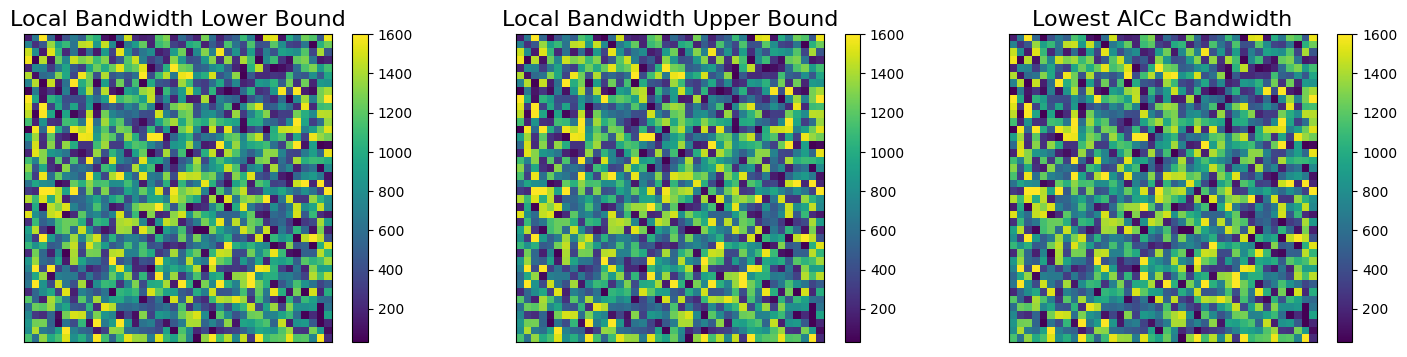

In [36]:
# Set global vmin and vmax for consistent coloring
all_data = [lower_2d, upper_2d, lowest_aicc_bandwidth_2d]
global_vmin = min(np.nanmin(arr) for arr in all_data)
global_vmax = max(np.nanmax(arr) for arr in all_data)

plot([lower_2d, upper_2d, lowest_aicc_bandwidth_2d],
    sub_title=['Local Bandwidth Lower Bound', 'Local Bandwidth Upper Bound', 'Lowest AICc Bandwidth'],
    size=size, vmin=global_vmin, vmax=global_vmax)